In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import physicsCalc as pc

In [24]:
solar_data = pd.read_csv('SOLAR_PLANT_DATA(GENERATION_AND_WEATHER).csv')  # adjust filename
solar_data['DATE_TIME'] = pd.to_datetime(solar_data['DATE_TIME'])
solar_data['DATE'] = solar_data['DATE_TIME'].dt.date

print(list(solar_data.columns))  
solar_data.head()

['DATE_TIME', 'PLANT_ID', 'IRRADIATION(W/m²)', 'AMBIENT_TEMPERATURE(°C)', 'MODULE_TEMPERATURE(°C)', 'DC_POWER(kW)', 'AC_POWER(kW)', 'DC_EFFICIENCY', 'AC_EFFICIENCY', 'INVERTOR_EFFICIENCY', 'EFFECTIVE_AREA(m²)', 'DAILY_YIELD(kWh)', 'TOTAL_YIELD(kWh)', 'DATE']


,DATE_TIME,PLANT_ID,IRRADIATION(W/m²),AMBIENT_TEMPERATURE(°C),MODULE_TEMPERATURE(°C),DC_POWER(kW),AC_POWER(kW),DC_EFFICIENCY,AC_EFFICIENCY,INVERTOR_EFFICIENCY,EFFECTIVE_AREA(m²),DAILY_YIELD(kWh),TOTAL_YIELD(kWh),DATE
0,2020-05-15 00:00:00,4136001,0.0,27.004764,25.060789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-05-15
1,2020-05-15 00:15:00,4136001,0.0,26.880811,24.421869,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-05-15
2,2020-05-15 00:30:00,4136001,0.0,26.682055,24.427290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-05-15
3,2020-05-15 00:45:00,4136001,0.0,26.500589,24.420678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-05-15
4,2020-05-15 01:00:00,4136001,0.0,26.596148,25.088210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-05-15


In [25]:

IRRADIATION_COL = 'IRRADIATION(W/m²)'
STANDARD_MERIDIAN = 82.5  # IST reference meridian (India fixed at UTC+5:30)

def equation_of_time_minutes(day_of_year):
    """Spencer's formula — corrects for Earth's elliptical orbit/axial tilt."""
    B = 2 * np.pi * (day_of_year - 1) / 365
    return 229.18 * (
        0.000075
        + 0.001868 * np.cos(B)
        - 0.032077 * np.sin(B)
        - 0.014615 * np.cos(2 * B)
        - 0.040849 * np.sin(2 * B)
    )

rows = []

for date, day_data in solar_data.groupby('DATE'):

    day_data = day_data.sort_values('DATE_TIME')

    daylight = day_data[day_data[IRRADIATION_COL] > 5]

    if daylight.empty:
        continue

    sunrise = daylight['DATE_TIME'].iloc[0]
    sunset = daylight['DATE_TIME'].iloc[-1]
    day_length_hrs = (sunset - sunrise).total_seconds() / 3600
    solar_noon = sunrise + (sunset - sunrise) / 2

    # Hour angle at sunset = half the day length, in degrees (15° per hour)
    hour_angle = (day_length_hrs / 2) * 15

    # Solar declination for this specific calendar date — captures season/time of year
    day_of_year = date.timetuple().tm_yday
    declination = 23.45 * np.sin(np.radians(360 / 365 * (284 + day_of_year)))

    # Solve the sunrise/sunset equation for latitude
    latitude = np.degrees(
        np.arctan(-np.cos(np.radians(hour_angle)) / np.tan(np.radians(declination)))
    )

    # Longitude from solar noon vs. clock noon, corrected for equation of time
    eot_minutes = equation_of_time_minutes(day_of_year)
    clock_hour_at_noon = solar_noon.hour + solar_noon.minute / 60
    longitude = STANDARD_MERIDIAN - (clock_hour_at_noon - 12 + eot_minutes / 60) * 15

    rows.append({
        'date': date,
        'day_of_year': day_of_year,
        'sunrise': sunrise.time(),
        'sunset': sunset.time(),
        'day_length_hrs': round(day_length_hrs, 2),
        'declination_deg': round(declination, 3),
        'latitude': latitude,
        'longitude': longitude,
    })

coord_table = pd.DataFrame(rows)

In [26]:
pd.set_option('display.max_rows', None)
print(f"\nUsable days: {len(coord_table)} / {solar_data['DATE'].nunique()} total\n")
print(coord_table.sort_values('date'))

implausible = coord_table[(coord_table['latitude'] < 5) | (coord_table['latitude'] > 38)]
if not implausible.empty:
    print(f"\n{len(implausible)} day(s) gave implausible latitude — inspect these:")
    print(implausible)



Usable days: 34 / 34 total

          date  day_of_year   sunrise    sunset  day_length_hrs  \
0   2020-05-15          136  06:00:00  18:15:00           12.25   
1   2020-05-16          137  06:00:00  17:30:00           11.50   
2   2020-05-17          138  06:00:00  18:15:00           12.25   
3   2020-05-18          139  07:00:00  18:30:00           11.50   
4   2020-05-19          140  06:00:00  18:30:00           12.50   
5   2020-05-20          141  06:00:00  18:30:00           12.50   
6   2020-05-21          142  06:00:00  18:30:00           12.50   
7   2020-05-22          143  06:00:00  18:15:00           12.25   
8   2020-05-23          144  06:00:00  18:15:00           12.25   
9   2020-05-24          145  06:00:00  18:30:00           12.50   
10  2020-05-25          146  06:00:00  18:00:00           12.00   
11  2020-05-26          147  06:00:00  18:30:00           12.50   
12  2020-05-27          148  06:00:00  18:30:00           12.50   
13  2020-05-28          149  06:0

In [27]:
def trim_outliers_iqr(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series >= lower) & (series <= upper)

lat_ok = trim_outliers_iqr(coord_table['latitude'])
lon_ok = trim_outliers_iqr(coord_table['longitude'])
trimmed_table = coord_table[lat_ok & lon_ok].copy()

print(f"\nTrimmed: kept {len(trimmed_table)} / {len(coord_table)} days")

trimmed_lat = trimmed_table['latitude'].median()
trimmed_lon = trimmed_table['longitude'].median()

final_lat = trimmed_lat
final_lon = trimmed_lon - .1 # fixed central-India longitude assumption

print(f"\nFinal coordinates: ({final_lat:.3f}°, {final_lon:.3f}°)")




Trimmed: kept 30 / 34 days

Final coordinates: (8.846°, 78.106°)


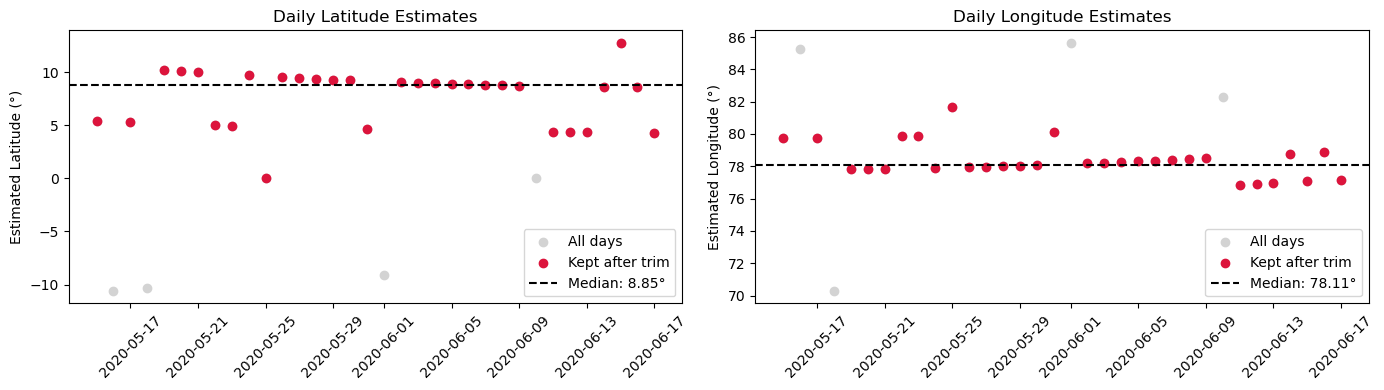

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(coord_table['date'], coord_table['latitude'], color='lightgray', label='All days')
axes[0].scatter(trimmed_table['date'], trimmed_table['latitude'], color='crimson', label='Kept after trim')
axes[0].axhline(final_lat, color='black', linestyle='--', label=f'Median: {final_lat:.2f}°')
axes[0].set_ylabel('Estimated Latitude (°)')
axes[0].set_title('Daily Latitude Estimates')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(coord_table['date'], coord_table['longitude'], color='lightgray', label='All days')
axes[1].scatter(trimmed_table['date'], trimmed_table['longitude'], color='crimson', label='Kept after trim')
axes[1].axhline(final_lon, color='black', linestyle='--', label=f'Median: {final_lon:.2f}°')
axes[1].set_ylabel('Estimated Longitude (°)')
axes[1].set_title('Daily Longitude Estimates')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [29]:
start_date = solar_data['DATE_TIME'].min().strftime('%Y-%m-%d')
end_date   = solar_data['DATE_TIME'].max().strftime('%Y-%m-%d')

url = (f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={final_lat}&longitude={final_lon}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&hourly=temperature_2m,shortwave_radiation,windspeed_10m,cloudcover"
    f"&timezone=auto"
)

res = requests.get(url).json()['hourly']

weather_hourly = pd.DataFrame({
    'TIMESTAMP': pd.to_datetime(res['time']),
    'AMBIENT_TEMPERATURE(°C)_API': res['temperature_2m'],
    'IRRADIATION(W/m²)_API': res['shortwave_radiation'],
    'WIND_SPEED(m/s)': res['windspeed_10m'],
    'CLOUD_COVER(%)': res['cloudcover'],
})

print(f"Pulled {len(weather_hourly)} hourly rows from {start_date} to {end_date}")

Pulled 816 hourly rows from 2020-05-15 to 2020-06-17


In [30]:

weather_hourly = weather_hourly.set_index('TIMESTAMP')
weather_15min = weather_hourly.resample('15min').interpolate(method='linear')
weather_15min = weather_15min.reset_index()

weather_15min.head()

,TIMESTAMP,AMBIENT_TEMPERATURE(°C)_API,IRRADIATION(W/m²)_API,WIND_SPEED(m/s),CLOUD_COVER(%)
0,2020-05-15 00:00:00,27.500,0.0,6.400,98.0
1,2020-05-15 00:15:00,27.375,0.0,6.575,98.0
2,2020-05-15 00:30:00,27.250,0.0,6.750,98.0
3,2020-05-15 00:45:00,27.125,0.0,6.925,98.0
4,2020-05-15 01:00:00,27.000,0.0,7.100,98.0


In [31]:

solar_data = pd.merge(
    solar_data,
    weather_15min[['TIMESTAMP', 'WIND_SPEED(m/s)', 'CLOUD_COVER(%)']],
    left_on='DATE_TIME',
    right_on='TIMESTAMP',
    how='left'
)

solar_data = solar_data.drop(columns=['DATE', 'TIMESTAMP'])

irr_index = solar_data.columns.get_loc(IRRADIATION_COL)

wind = solar_data.pop('WIND_SPEED(m/s)')
cloud = solar_data.pop('CLOUD_COVER(%)')

solar_data.insert(irr_index + 1, 'WIND_SPEED(m/s)', wind)
solar_data.insert(irr_index + 2, 'CLOUD_COVER(%)', cloud)

solar_data.iloc[700:720]

,DATE_TIME,PLANT_ID,IRRADIATION(W/m²),WIND_SPEED(m/s),CLOUD_COVER(%),AMBIENT_TEMPERATURE(°C),MODULE_TEMPERATURE(°C),DC_POWER(kW),AC_POWER(kW),DC_EFFICIENCY,AC_EFFICIENCY,INVERTOR_EFFICIENCY,EFFECTIVE_AREA(m²),DAILY_YIELD(kWh),TOTAL_YIELD(kWh)
700,2020-05-22 07:30:00,4136001,331.570986,5.600,44.50,25.862897,31.228512,7134.977143,7009.609524,0.267925,0.269810,0.263217,21518.701687,5318.699167,722969.357457
701,2020-05-22 07:45:00,4136001,386.911248,5.650,42.25,26.552563,34.141818,8471.410000,8308.887619,0.318109,0.319822,0.312006,21894.969571,7395.921071,725046.579361
702,2020-05-22 08:00:00,4136001,424.425203,5.700,40.00,27.161824,35.932539,9668.130000,9477.212857,0.363047,0.364792,0.355878,22779.349434,9765.224286,727415.882576
703,2020-05-22 08:15:00,4136001,467.481100,6.725,37.50,27.541916,36.801919,11018.011429,10795.281905,0.413736,0.415527,0.405373,23568.891740,12464.044762,730114.703052
704,2020-05-22 08:30:00,4136001,525.042073,7.750,35.00,27.826928,38.308498,12664.146667,12401.880000,0.475550,0.477367,0.465702,24120.251148,15564.514762,733215.173052
705,2020-05-22 08:45:00,4136001,589.840081,8.775,32.50,28.181958,40.664267,13796.141905,13503.898095,0.518058,0.519785,0.507084,23389.631090,18940.489286,736591.147576
706,2020-05-22 09:00:00,4136001,650.150780,9.800,30.00,28.849683,43.654425,12985.117619,12704.272857,0.487603,0.489007,0.477057,19972.471041,22116.557500,739767.215790
707,2020-05-22 09:15:00,4136001,713.910318,9.550,34.25,29.241733,47.507955,12854.320000,12571.300000,0.482692,0.483888,0.472064,18005.510883,25259.382500,742910.040790
708,2020-05-22 09:30:00,4136001,760.793342,9.300,38.50,29.783513,49.504854,12496.496190,12217.949524,0.469255,0.470287,0.458795,16425.611925,28313.869881,745964.528171
709,2020-05-22 09:45:00,4136001,802.964108,9.050,42.75,30.145208,51.536908,12764.625714,12476.745714,0.479323,0.480249,0.468513,15896.882043,31433.056310,749083.714599


In [32]:
DEFAULT_MODULE_EFFICIENCY = 0.18
if 'EFFECTIVE_AREA(m²)' in solar_data.columns:
    SYSTEM_CAPACITY_KWP = solar_data['EFFECTIVE_AREA(m²)'] * DEFAULT_MODULE_EFFICIENCY
else:
    SYSTEM_CAPACITY_KWP = 1.0

# 2. Run the calculations behind the scenes (Original structure kept)
theo_mod_temp = solar_data.apply(
    lambda row: pc.estimate_module_temperature(
        ambient_temp_c=row['AMBIENT_TEMPERATURE(°C)'],
        irradiance_wm2=row['IRRADIATION(W/m²)'],
        wind_speed_ms=row.get('WIND_SPEED(m/s)', None) # Passes wind if it exists
    ),
    axis=1
)

# Keep the original fractional performance ratio (per kWp)
theo_dc_per_kwp = solar_data.apply(
    lambda row: pc.calculate_dc_power_per_kwp(
        irradiance_wm2=row['IRRADIATION(W/m²)'],
        module_temp_c=theo_mod_temp[row.name]
    ),
    axis=1
)

In [33]:
theo_ac_per_kwp = theo_dc_per_kwp * solar_data['INVERTOR_EFFICIENCY']

# Multiply the ratios by the dynamic capacity to get absolute kW (bringing it to thousands)
# Now these are defined BEFORE we try to insert them!
theo_dc = theo_dc_per_kwp * SYSTEM_CAPACITY_KWP
theo_ac = theo_ac_per_kwp * SYSTEM_CAPACITY_KWP

# Rename existing matching columns to 'ACTUAL' to avoid confusion
solar_data = solar_data.rename(columns={
    'MODULE_TEMPERATURE(°C)': 'ACTUAL_MODULE_TEMPERATURE(°C)',
    'DC_POWER(kW)': 'ACTUAL_DC_POWER(kW)',
    'AC_POWER(kW)': 'ACTUAL_AC_POWER(kW)'
})

# Insert the new physics columns precisely where you want them
# Theoretical Module Temp goes directly to the left of Actual Module Temp
idx_mod_temp = solar_data.columns.get_loc('ACTUAL_MODULE_TEMPERATURE(°C)')
solar_data.insert(idx_mod_temp, 'THEORETICAL_MODULE_TEMPERATURE(°C)', theo_mod_temp)

# Theoretical DC & AC go together right before Actual DC & AC
idx_dc_power = solar_data.columns.get_loc('ACTUAL_DC_POWER(kW)')
solar_data.insert(idx_dc_power, 'THEORETICAL_DC_POWER(kW)', theo_dc)
solar_data.insert(idx_dc_power + 1, 'THEORETICAL_AC_POWER(kW)', theo_ac)

# Add the per-kWp fractional metrics and the calculated capacity tracker
solar_data['THEORETICAL_DC_PER_KWP'] = theo_dc_per_kwp
solar_data['THEORETICAL_AC_PER_KWP'] = theo_ac_per_kwp
solar_data['CALCULATED_PLANT_CAPACITY(kWp)'] = SYSTEM_CAPACITY_KWP

# Append the engineering Residual columns to the end of the dataframe
solar_data['DC_RESIDUAL(kW)'] = solar_data['ACTUAL_DC_POWER(kW)'] - solar_data['THEORETICAL_DC_POWER(kW)']
solar_data['AC_RESIDUAL(kW)'] = solar_data['ACTUAL_AC_POWER(kW)'] - solar_data['THEORETICAL_AC_POWER(kW)']

In [34]:
print("Updated Column Layout Map:")
for i, col in enumerate(solar_data.columns):
    print(f" {i:02d} -> {col}")

solar_data.iloc[200:220]

Updated Column Layout Map:
 00 -> DATE_TIME
 01 -> PLANT_ID
 02 -> IRRADIATION(W/m²)
 03 -> WIND_SPEED(m/s)
 04 -> CLOUD_COVER(%)
 05 -> AMBIENT_TEMPERATURE(°C)
 06 -> THEORETICAL_MODULE_TEMPERATURE(°C)
 07 -> ACTUAL_MODULE_TEMPERATURE(°C)
 08 -> THEORETICAL_DC_POWER(kW)
 09 -> THEORETICAL_AC_POWER(kW)
 10 -> ACTUAL_DC_POWER(kW)
 11 -> ACTUAL_AC_POWER(kW)
 12 -> DC_EFFICIENCY
 13 -> AC_EFFICIENCY
 14 -> INVERTOR_EFFICIENCY
 15 -> EFFECTIVE_AREA(m²)
 16 -> DAILY_YIELD(kWh)
 17 -> TOTAL_YIELD(kWh)
 18 -> THEORETICAL_DC_PER_KWP
 19 -> THEORETICAL_AC_PER_KWP
 20 -> CALCULATED_PLANT_CAPACITY(kWp)
 21 -> DC_RESIDUAL(kW)
 22 -> AC_RESIDUAL(kW)


,DATE_TIME,PLANT_ID,IRRADIATION(W/m²),WIND_SPEED(m/s),CLOUD_COVER(%),AMBIENT_TEMPERATURE(°C),THEORETICAL_MODULE_TEMPERATURE(°C),ACTUAL_MODULE_TEMPERATURE(°C),THEORETICAL_DC_POWER(kW),THEORETICAL_AC_POWER(kW),...,AC_EFFICIENCY,INVERTOR_EFFICIENCY,EFFECTIVE_AREA(m²),DAILY_YIELD(kWh),TOTAL_YIELD(kWh),THEORETICAL_DC_PER_KWP,THEORETICAL_AC_PER_KWP,CALCULATED_PLANT_CAPACITY(kWp),DC_RESIDUAL(kW),AC_RESIDUAL(kW)
200,2020-05-17 02:15:00,4136001,0.000000,16.950,100.0,24.467926,24.467926,22.172177,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
201,2020-05-17 02:30:00,4136001,0.000000,16.300,100.0,24.254664,24.254664,21.830828,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
202,2020-05-17 02:45:00,4136001,0.000000,15.650,100.0,24.288478,24.288478,22.096860,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
203,2020-05-17 03:00:00,4136001,0.000000,15.000,100.0,24.180007,24.180007,22.021513,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
204,2020-05-17 03:15:00,4136001,0.000000,14.125,100.0,23.952259,23.952259,21.718280,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
205,2020-05-17 03:30:00,4136001,0.000000,13.250,100.0,24.118319,24.118319,22.020067,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
206,2020-05-17 03:45:00,4136001,0.000000,12.375,100.0,24.318871,24.318871,22.570318,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
207,2020-05-17 04:00:00,4136001,0.000000,11.500,100.0,24.366302,24.366302,22.701634,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
208,2020-05-17 04:15:00,4136001,0.044788,10.825,100.0,24.637875,24.638328,23.122368,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000045,0.000000,0.000000,0.000000,0.000000
209,2020-05-17 04:30:00,4136001,0.000000,10.150,100.0,24.727734,24.727734,23.304269,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,301422.799286,0.000000,0.000000,0.000000,0.000000,0.000000
